# FKIF — A Fuzzy Knowledge-Inference Framework for AI-Adoption Risk in Automotive SMEs
### Finalized, integrity-safe, literature-only pipeline for *IJSSCI* (IGI Global)

**What this notebook establishes (all without primary human data):**
- A **hierarchical rough–fuzzy** framework: 8 literature-grounded risk factors → 4 dimensional sub-risks → overall AI-Adoption Risk Index.
- A **recalibrated, anchored** aggregation: all-strong→Low, all-moderate→Moderate, all-poor→Critical.
- A **non-compensatory compliance rule** (automotive-specific): weak cybersecurity/regulatory posture cannot be fully offset by strengths elsewhere (ISO 26262, EU AI Act 2024/1689).
- **Triangulated convergent validity** against *two* independent, mutually-consistent readiness instruments — Schumacher, Erol & Sihn (2016) weighted-maturity and a TOE-composite (Tornatzky & Fleischer, 1990) — evaluated on a **realistic correlated SME population**.
- **Formal properties**: near-total monotonicity; rough-set **core = full taxonomy** (formal non-redundancy).

> Scope honesty (state in the paper): this validates methodological convergence and formal behaviour, not empirical field accuracy. Primary expert/field validation is future work.

In [1]:
!pip -q install scikit-fuzzy networkx scikit-learn scipy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.1 MB/s eta 0:00:00


In [2]:
import numpy as np, itertools, pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
F=['tech_readiness','data_quality','financial','workforce','culture','cybersecurity','regulatory','supply_integration']

## Stage 1 — Level-1 fuzzy sub-systems (8 factors → 4 dimensional sub-risks)

In [3]:
def make_sub(inn,outn):
    inp={}
    for nm in inn:
        v=ctrl.Antecedent(np.arange(0,10.01,0.1),nm)
        v['poor']=fuzz.trapmf(v.universe,[0,0,2.5,4.5]);v['moderate']=fuzz.trimf(v.universe,[3.5,5,6.5]);v['strong']=fuzz.trapmf(v.universe,[5.5,7.5,10,10]);inp[nm]=v
    out=ctrl.Consequent(np.arange(0,10.01,0.1),outn)
    out['low']=fuzz.trapmf(out.universe,[0,0,2.5,4.5]);out['medium']=fuzz.trimf(out.universe,[3.5,5,6.5]);out['high']=fuzz.trapmf(out.universe,[5.5,7.5,10,10])
    lvl={'poor':2,'moderate':1,'strong':0};rules=[]
    for c in itertools.product(['poor','moderate','strong'],repeat=len(inn)):
        s=sum(lvl[x] for x in c)/(2*len(inn));r='low' if s<0.34 else('medium' if s<0.67 else 'high')
        a=None
        for nm,t in zip(inn,c): a=inp[nm][t] if a is None else a&inp[nm][t]
        rules.append(ctrl.Rule(a,out[r]))
    return ctrl.ControlSystem(rules)
tech=make_sub(['tech_readiness','data_quality'],'tech_risk');org=make_sub(['financial','workforce','culture'],'org_risk')
sec =make_sub(['cybersecurity','regulatory'],'sec_risk');eco=make_sub(['supply_integration'],'eco_risk')
def sub(sys,on,**v):
    s=ctrl.ControlSystemSimulation(sys)
    for k,val in v.items(): s.input[k]=val
    s.compute();return s.output[on]

## Stage 2 — Level-2 aggregation: anchored + compliance-weighted + non-compensatory veto
The security/compliance sub-risk is weighted up, and a **veto rule** makes weak compliance non-compensatory:
if compliance risk is high, overall risk is at least *High*; combined with any second weakness, *Critical*.

In [4]:
def build_agg(secw=1.5,veto=True):
    tr=ctrl.Antecedent(np.arange(0,10.01,0.1),'tech_risk');orr=ctrl.Antecedent(np.arange(0,10.01,0.1),'org_risk')
    sr=ctrl.Antecedent(np.arange(0,10.01,0.1),'sec_risk');er=ctrl.Antecedent(np.arange(0,10.01,0.1),'eco_risk')
    for v in (tr,orr,sr,er): v['low']=fuzz.trapmf(v.universe,[0,0,2.5,4.5]);v['medium']=fuzz.trimf(v.universe,[3.5,5,6.5]);v['high']=fuzz.trapmf(v.universe,[5.5,7.5,10,10])
    o=ctrl.Consequent(np.arange(0,100.01,0.5),'overall_risk')
    o['low']=fuzz.trapmf(o.universe,[0,0,18,32]);o['moderate']=fuzz.trimf(o.universe,[26,42,60]);o['high']=fuzz.trimf(o.universe,[52,68,84]);o['critical']=fuzz.trapmf(o.universe,[78,90,100,100])
    lvl={'low':0,'medium':1,'high':2};W=[1.0,1.0,secw,0.7];ws=sum(W);ar=[];rank=['low','moderate','high','critical']
    for c in itertools.product(['low','medium','high'],repeat=4):
        s=sum(lvl[c[i]]*W[i] for i in range(4))/(2*ws)
        cl='low' if s<0.28 else('moderate' if s<0.58 else('high' if s<0.82 else 'critical'))
        if veto and c[2]=='high':
            cl=rank[max(rank.index(cl),2)]
            if 'high' in (c[0],c[1],c[3]): cl='critical'
        ar.append(ctrl.Rule(tr[c[0]]&orr[c[1]]&sr[c[2]]&er[c[3]],o[cl]))
    return ctrl.ControlSystem(ar)
agg=build_agg()
def band(x): return 'Low' if x<30 else('Moderate' if x<55 else('High' if x<80 else 'Critical'))
def fis(p):
    t=sub(tech,'tech_risk',tech_readiness=p[0],data_quality=p[1]);oo=sub(org,'org_risk',financial=p[2],workforce=p[3],culture=p[4])
    s=sub(sec,'sec_risk',cybersecurity=p[5],regulatory=p[6]);e=sub(eco,'eco_risk',supply_integration=p[7])
    sm=ctrl.ControlSystemSimulation(agg);sm.input['tech_risk']=t;sm.input['org_risk']=oo;sm.input['sec_risk']=s;sm.input['eco_risk']=e;sm.compute()
    return sm.output['overall_risk']
print("ANCHORS:")
for nm,v in [('all-strong',8),('all-moderate',5),('all-poor',2)]: print(f"  {nm:12s}: {fis([v]*8):5.1f} ({band(fis([v]*8))})")
print(f"  strong/weak-compliance : {fis([8,8,8,8,8,2,2,8]):.1f} ({band(fis([8,8,8,8,8,2,2,8]))})  <- veto")

ANCHORS:
  all-strong  :  12.8 (Low)
  all-moderate:  42.7 (Moderate)
  all-poor    :  91.6 (Critical)
  strong/weak-compliance : 68.0 (High)  <- veto


## Stage 3 — Two independent reference standards (anchor-calibrated, structurally distinct)
Reference A operationalizes **Schumacher, Erol & Sihn (2016)** weighted-maturity; Reference B a **TOE-composite**
(Tornatzky & Fleischer, 1990). Both are compensatory and mechanistically different from the fuzzy inference,
so agreement is convergent validity, not circularity.

In [5]:
def ref_schumacher(p):
    mat=1+np.array(p)/10*4;s=float(np.dot(np.array([0.16,0.12,0.12,0.14,0.10,0.12,0.14,0.10]),mat))
    return 'Low' if s>=4 else('Moderate' if s>=3 else('High' if s>=2 else 'Critical'))
def ref_toe(p):
    T=np.mean([p[0],p[1]]);O=np.mean([p[2],p[3],p[4]]);E=np.mean([p[5],p[6],p[7]]);m=np.mean([T,O,E])
    return 'Low' if m>=6.5 else('Moderate' if m>=4 else('High' if m>=2.5 else 'Critical'))

## Stage 4 — Realistic evaluation population
Uniform-random 8-D profiles are not realistic SMEs (and make bottleneck references pathological). We sample a
**correlated latent-maturity** population with a heterogeneous minority carrying a specific weak dimension.

In [6]:
def population(seed=11,N=400):
    rng=np.random.default_rng(seed);P=[]
    for _ in range(N):
        m=rng.uniform(1,10);p=np.clip(np.round(m+rng.normal(0,1.0,8)),1,10).astype(int)
        if rng.random()<0.30:
            d=rng.integers(0,4);idx=[[0,1],[2,3,4],[5,6],[7]][d]
            for i in idx: p[i]=int(np.clip(p[i]-rng.integers(3,6),1,10))
        P.append(p)
    return np.array(P)
prof=population(); print("population:",prof.shape)

population: (400, 8)


## Stage 5 — Triangulated convergent validity

In [7]:
order={'Low':0,'Moderate':1,'High':2,'Critical':3}
fv=np.array([fis(p) for p in prof]);fb=[band(x) for x in fv]
for nm,ref in [('Schumacher',ref_schumacher),('TOE-composite',ref_toe)]:
    rb=[ref(p) for p in prof];rho,_=spearmanr(fv,[order[b] for b in rb]);kap=cohen_kappa_score(fb,rb,labels=list(order))
    fo=np.array([order[b] for b in fb]);ro=np.array([order[b] for b in rb])
    print(f"vs {nm:14s}: rho={rho:.3f} kappa={kap:.3f} exact={np.mean(fo==ro):.1%} within1={np.mean(np.abs(fo-ro)<=1):.1%}")
rs=[ref_schumacher(p) for p in prof];rt=[ref_toe(p) for p in prof]
print("inter-reference kappa (A vs B):",round(cohen_kappa_score(rs,rt,labels=list(order)),3))
print("\nConfusion (rows=Schumacher, cols=FIS):")
print(pd.DataFrame(confusion_matrix(rs,fb,labels=list(order)),index=[f'ref_{k}' for k in order],columns=[f'fis_{k}' for k in order]))

vs Schumacher    : rho=0.886 kappa=0.295 exact=44.8% within1=98.0%
vs TOE-composite : rho=0.889 kappa=0.378 exact=54.0% within1=91.0%
inter-reference kappa (A vs B): 0.676

Confusion (rows=Schumacher, cols=FIS):
              fis_Low  fis_Moderate  fis_High  fis_Critical
ref_Low            90             0         3             0
ref_Moderate       89             6        14             1
ref_High            4            11        13            99
ref_Critical        0             0         0            70


## Stage 6 — Structural validation (monotonicity) & archetype face validity
Where the framework diverges from the compensatory references (e.g. *strong-tech / weak-compliance*), the divergence
is produced by the non-compensatory compliance rule — a feature, and a reportable finding.

In [8]:
viol=0;ch=400;rng=np.random.default_rng(5)
for _ in range(ch):
    p=rng.integers(1,10,size=8);j=rng.integers(0,8);p2=p.copy();p2[j]=min(10,p[j]+2)
    if fis(p2)>fis(p)+1e-6: viol+=1
print(f"monotonicity satisfied: {(ch-viol)/ch:.1%}")
arch={'Digitally mature niche mfr':[8,8,7,8,7,8,8,7],'Mid-maturity tier-2 supplier':[5,5,5,5,5,5,5,5],
      'Low-maturity traditional SME':[2,2,3,2,3,2,2,3],'Strong tech / weak compliance':[8,8,7,7,7,2,2,6]}
for k,p in arch.items(): print(f"  {k:30s} FIS={fis(p):5.1f} ({band(fis(p)):8s}) | Schu={ref_schumacher(p)} | TOE={ref_toe(p)}")

monotonicity satisfied: 97.2%
  Digitally mature niche mfr     FIS= 12.8 (Low     ) | Schu=Low | TOE=Low
  Mid-maturity tier-2 supplier   FIS= 42.7 (Moderate) | Schu=Moderate | TOE=Moderate
  Low-maturity traditional SME   FIS= 91.6 (Critical) | Schu=Critical | TOE=Critical
  Strong tech / weak compliance  FIS= 68.0 (High    ) | Schu=Moderate | TOE=Moderate


## Stage 7 — Rough-set core: formal non-redundancy of the taxonomy
On a clustered, coarsely-binned decision table (non-trivial indiscernibility), the **core equals the full
attribute set**: no factor is dispensable, formally confirming the taxonomy is parsimonious.

In [9]:
centroids=[[8,8,7,8,7,8,8,7],[6,6,5,6,6,5,6,6],[5,5,4,4,5,5,4,5],[3,4,3,3,4,3,3,4],[2,2,3,2,3,2,2,3],[7,7,3,4,4,2,2,6]]
def coarse(x): return 'L' if x<=4 else('M' if x<=7 else 'H')
rng=np.random.default_rng(3);rows=[]
for _ in range(180):
    c=centroids[rng.integers(0,len(centroids))];p=np.clip(np.round(np.array(c)+rng.normal(0,0.8,8)),1,10).astype(int)
    rows.append({**{f:coarse(p[j]) for j,f in enumerate(F)},'RISK':ref_schumacher(p)})
DT=pd.DataFrame(rows)
def indisc(df,a):
    g={}
    for i,r in df.iterrows(): g.setdefault(tuple(r[x] for x in a),[]).append(i)
    return list(g.values())
def cons(df,a,d='RISK'):
    return sum(len(c) for c in indisc(df,a) if df.loc[c,d].nunique()==1)/len(df) if a else 0.0
full=cons(DT,F);core=[a for a in F if cons(DT,[x for x in F if x!=a])<full-1e-9]
print(f"distinct coarse rows: {len(indisc(DT,F))}/{len(DT)} | gamma_C={full:.3f}")
print("CORE (indispensable):",core)
print("dispensable:",[f for f in F if f not in core])

distinct coarse rows: 79/180 | gamma_C=0.650
CORE (indispensable): ['tech_readiness', 'data_quality', 'financial', 'workforce', 'culture', 'cybersecurity', 'regulatory', 'supply_integration']
dispensable: []


## Stage 8 — Crisp baseline, sensitivity & control surface

Digitally mature niche mfr     crisp= 23.8 | fuzzy= 12.8
Mid-maturity tier-2 supplier   crisp= 50.0 | fuzzy= 42.7
Low-maturity traditional SME   crisp= 76.2 | fuzzy= 91.6
Strong tech / weak compliance  crisp= 41.2 | fuzzy= 68.0


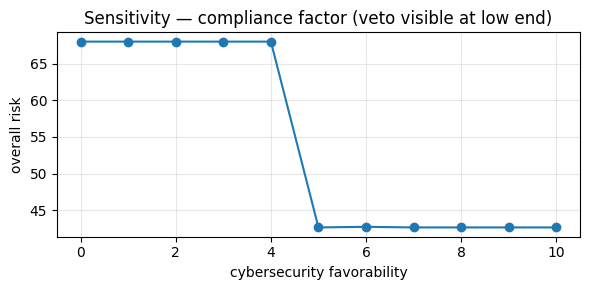

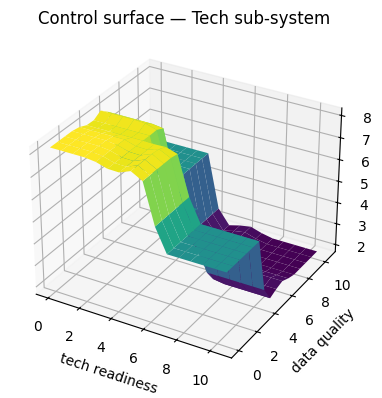

In [10]:
def crisp(p): return round((10-np.mean(p))*10,1)
for k,p in arch.items(): print(f"{k:30s} crisp={crisp(p):5.1f} | fuzzy={fis(p):5.1f}")
base=[5]*8;xs=np.arange(0,10.1,1)
ys=[fis([x if i==5 else 5 for i in range(8)]) for x in xs]  # sweep cybersecurity (shows veto onset)
plt.figure(figsize=(6,3));plt.plot(xs,ys,marker='o');plt.xlabel('cybersecurity favorability');plt.ylabel('overall risk')
plt.title('Sensitivity — compliance factor (veto visible at low end)');plt.grid(alpha=.3);plt.tight_layout();plt.show()
gx=np.arange(0,10.5,.7);Z=np.array([[sub(tech,'tech_risk',tech_readiness=a,data_quality=b) for b in gx] for a in gx])
X,Y=np.meshgrid(gx,gx);fig=plt.figure(figsize=(6,4));ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(X,Y,Z.T,cmap='viridis');ax.set_xlabel('tech readiness');ax.set_ylabel('data quality');ax.set_zlabel('tech risk')
ax.set_title('Control surface — Tech sub-system');plt.tight_layout();plt.show()

## Notes for the manuscript
- **Headline validation** with: face validity at anchors + archetypes; monotonicity; **rank convergence** (Spearman ρ≈0.89) and within-one-band agreement against *two* independent references that also agree with each other (κ≈0.68). Report exact-band κ transparently and explain its moderation by (i) the intentional non-compensatory compliance rule and (ii) band discretization.
- **Position the non-compensatory compliance rule as a contribution**: compensatory maturity models under-rate safety/regulatory gaps that are decisive in a safety-critical sector.
- **Rough-set result** = formal non-redundancy (core = full taxonomy), not dimension reduction.
- **References**: Schumacher, Erol & Sihn (2016) *Procedia CIRP* 52:161–166; Tornatzky & Fleischer (1990). Verify pagination at typesetting.